In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [6]:
df = pd.read_csv("creditcard.csv")
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,281167.000000,...,281167.000000,281167.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000,281166.000000
mean,93823.473036,-0.000490,-0.004829,0.010208,0.001872,-0.003643,0.001853,-0.001489,-0.000453,-0.000139,...,-0.000152,-0.001122,-0.000658,-0.000287,0.001808,0.000052,-0.000026,-0.000007,88.636666,0.001746
std,46984.722160,1.956923,1.651050,1.513663,1.415779,1.378519,1.330868,1.234843,1.191939,1.099999,...,0.735420,0.724604,0.626269,0.605912,0.520640,0.482668,0.403576,0.330547,250.199065,0.041752
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,53806.000000,-0.920419,-0.601691,-0.876622,-0.848351,-0.695718,-0.766271,-0.555334,-0.207747,-0.644757,...,-0.228028,-0.541219,-0.162176,-0.354603,-0.314985,-0.327427,-0.070751,-0.052754,5.690000,0.000000
50%,83803.000000,0.019150,0.063320,0.191483,-0.016544,-0.059012,-0.271461,0.037916,0.022928,-0.052296,...,-0.029718,0.005952,-0.011750,0.041260,0.019832,-0.052788,0.001464,0.011488,22.080000,0.000000
75%,138161.000000,1.311918,0.799451,1.034872,0.748386,0.607208,0.400851,0.567684,0.327050,0.598312,...,0.185190,0.525308,0.146637,0.438420,0.351927,0.241803,0.090713,0.078110,77.740000,0.000000
max,169979.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [9]:
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(df[df['Class'] == 1])))
print('Valid Transactions: {}'.format(len(df[df['Class'] == 0])))

0.0017493542353255545
Fraud Cases: 491
Valid Transactions: 280675


In [10]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


,Amount
count,491.000000
mean,122.373605
std,256.919810
min,0.000000
25%,1.000000
50%,9.210000
75%,105.890000
max,2125.870000


In [11]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


,Amount
count,280675.000000
mean,88.577648
std,250.183633
min,0.000000
25%,5.740000
50%,22.080000
75%,77.650000
max,25691.160000


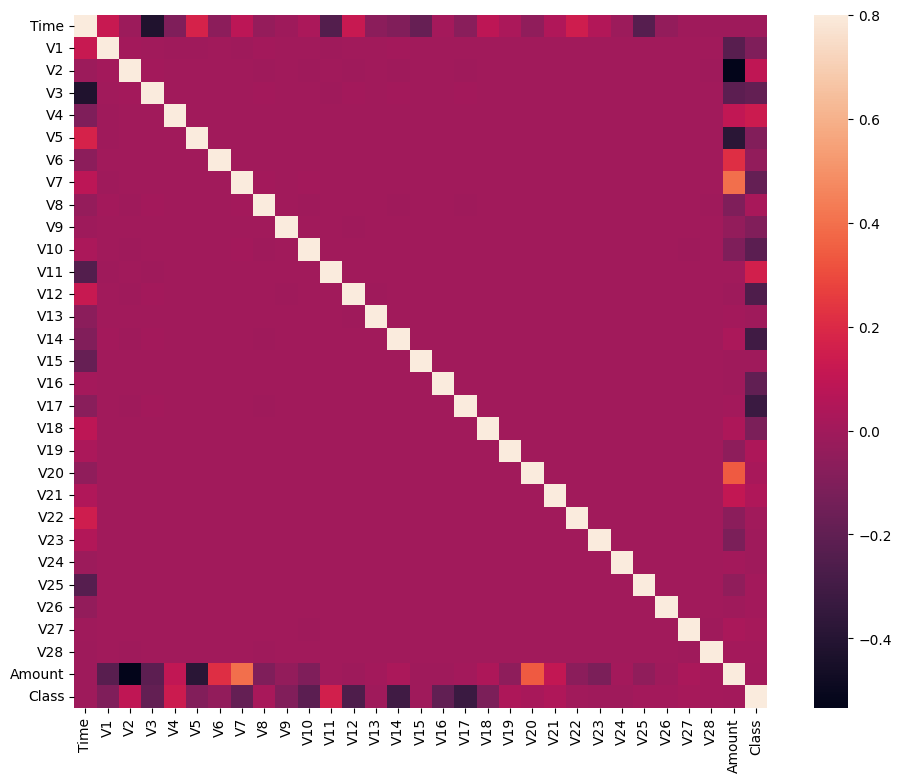

In [12]:
corrmat = df.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [15]:
X = df.drop(['Class'], axis = 1)
Y = df["Class"]
print(X.shape)
print(Y.shape)

xData = X.values
yData = Y.values

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(xData, yData, test_size = 0.2, random_state = 42)

(281167, 30)
(281167,)


In [18]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

# Identify and remove NaN values from yTrain and corresponding rows from xTrain
nan_mask = np.isnan(yTrain)
xTrain_cleaned = xTrain[~nan_mask]
yTrain_cleaned = yTrain[~nan_mask]

rfc.fit(xTrain_cleaned, yTrain_cleaned)

yPred = rfc.predict(xTest)

KeyboardInterrupt: 

To check for `NaN` values in your `df` DataFrame, you can use `df.isnull().sum()`:

In [19]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [20]:
# To remove rows with NaN values in the 'Class' column
df_cleaned = df.dropna(subset=['Class']).copy()

print('Original DataFrame shape:', df.shape)
print('Cleaned DataFrame shape:', df_cleaned.shape)
print('\nNaN values after cleaning:')
print(df_cleaned.isnull().sum())

Original DataFrame shape: (281167, 31)
Cleaned DataFrame shape: (281166, 31)

NaN values after cleaning:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [21]:
X = df_cleaned.drop(['Class'], axis = 1)
Y = df_cleaned["Class"]
print(X.shape)
print(Y.shape)

xData = X.values
yData = Y.values

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)

(281166, 30)
(281166,)


In [22]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(xTrain, yTrain)

yPred = rfc.predict(xTest)

Model Evaluation Metrics:
Accuracy: 0.9995
Precision: 0.9595
Recall: 0.7553
F1-Score: 0.8452
Matthews Correlation Coefficient: 0.8511


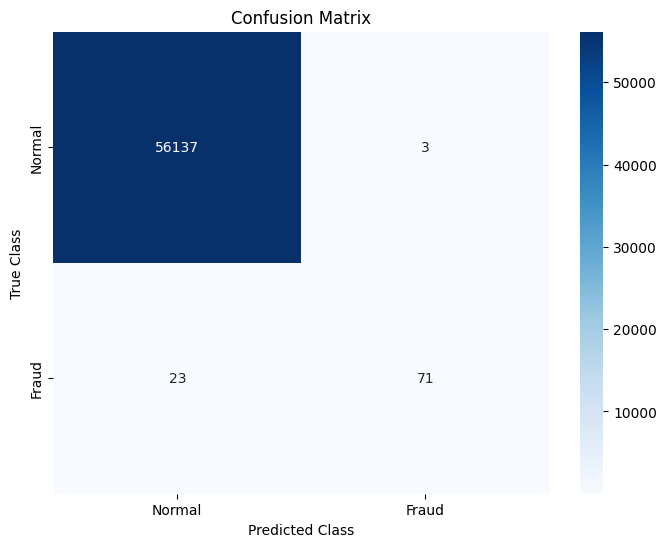

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()